*Water Quality Classification using Machine Learning*

*Import Required Libraries*

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


*Read Dataset*

In [147]:
df=pd.read_csv("C:/Intel/water_quality.csv")
df.head(15)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


*Shape Of Data set*

In [148]:
df.shape

(3276, 10)

*Information Of Data Set*

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


*Describe Of Data Set*

In [150]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [151]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


*Fill Missing Values*

In [152]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

*Calculate Of Percent Of Missing Values*

In [153]:
def calculate_missing_percent(df):
    nan_percent = 100 * df.isnull().sum() / len(df)
    nan_percent = nan_percent[nan_percent>0].sort_values()

    return nan_percent



In [154]:
nan_percent = calculate_missing_percent(df)

In [155]:
nan_percent

Trihalomethanes     4.945055
ph                 14.987790
Sulfate            23.840049
dtype: float64

(np.float64(0.0), np.float64(25.03205128205128))

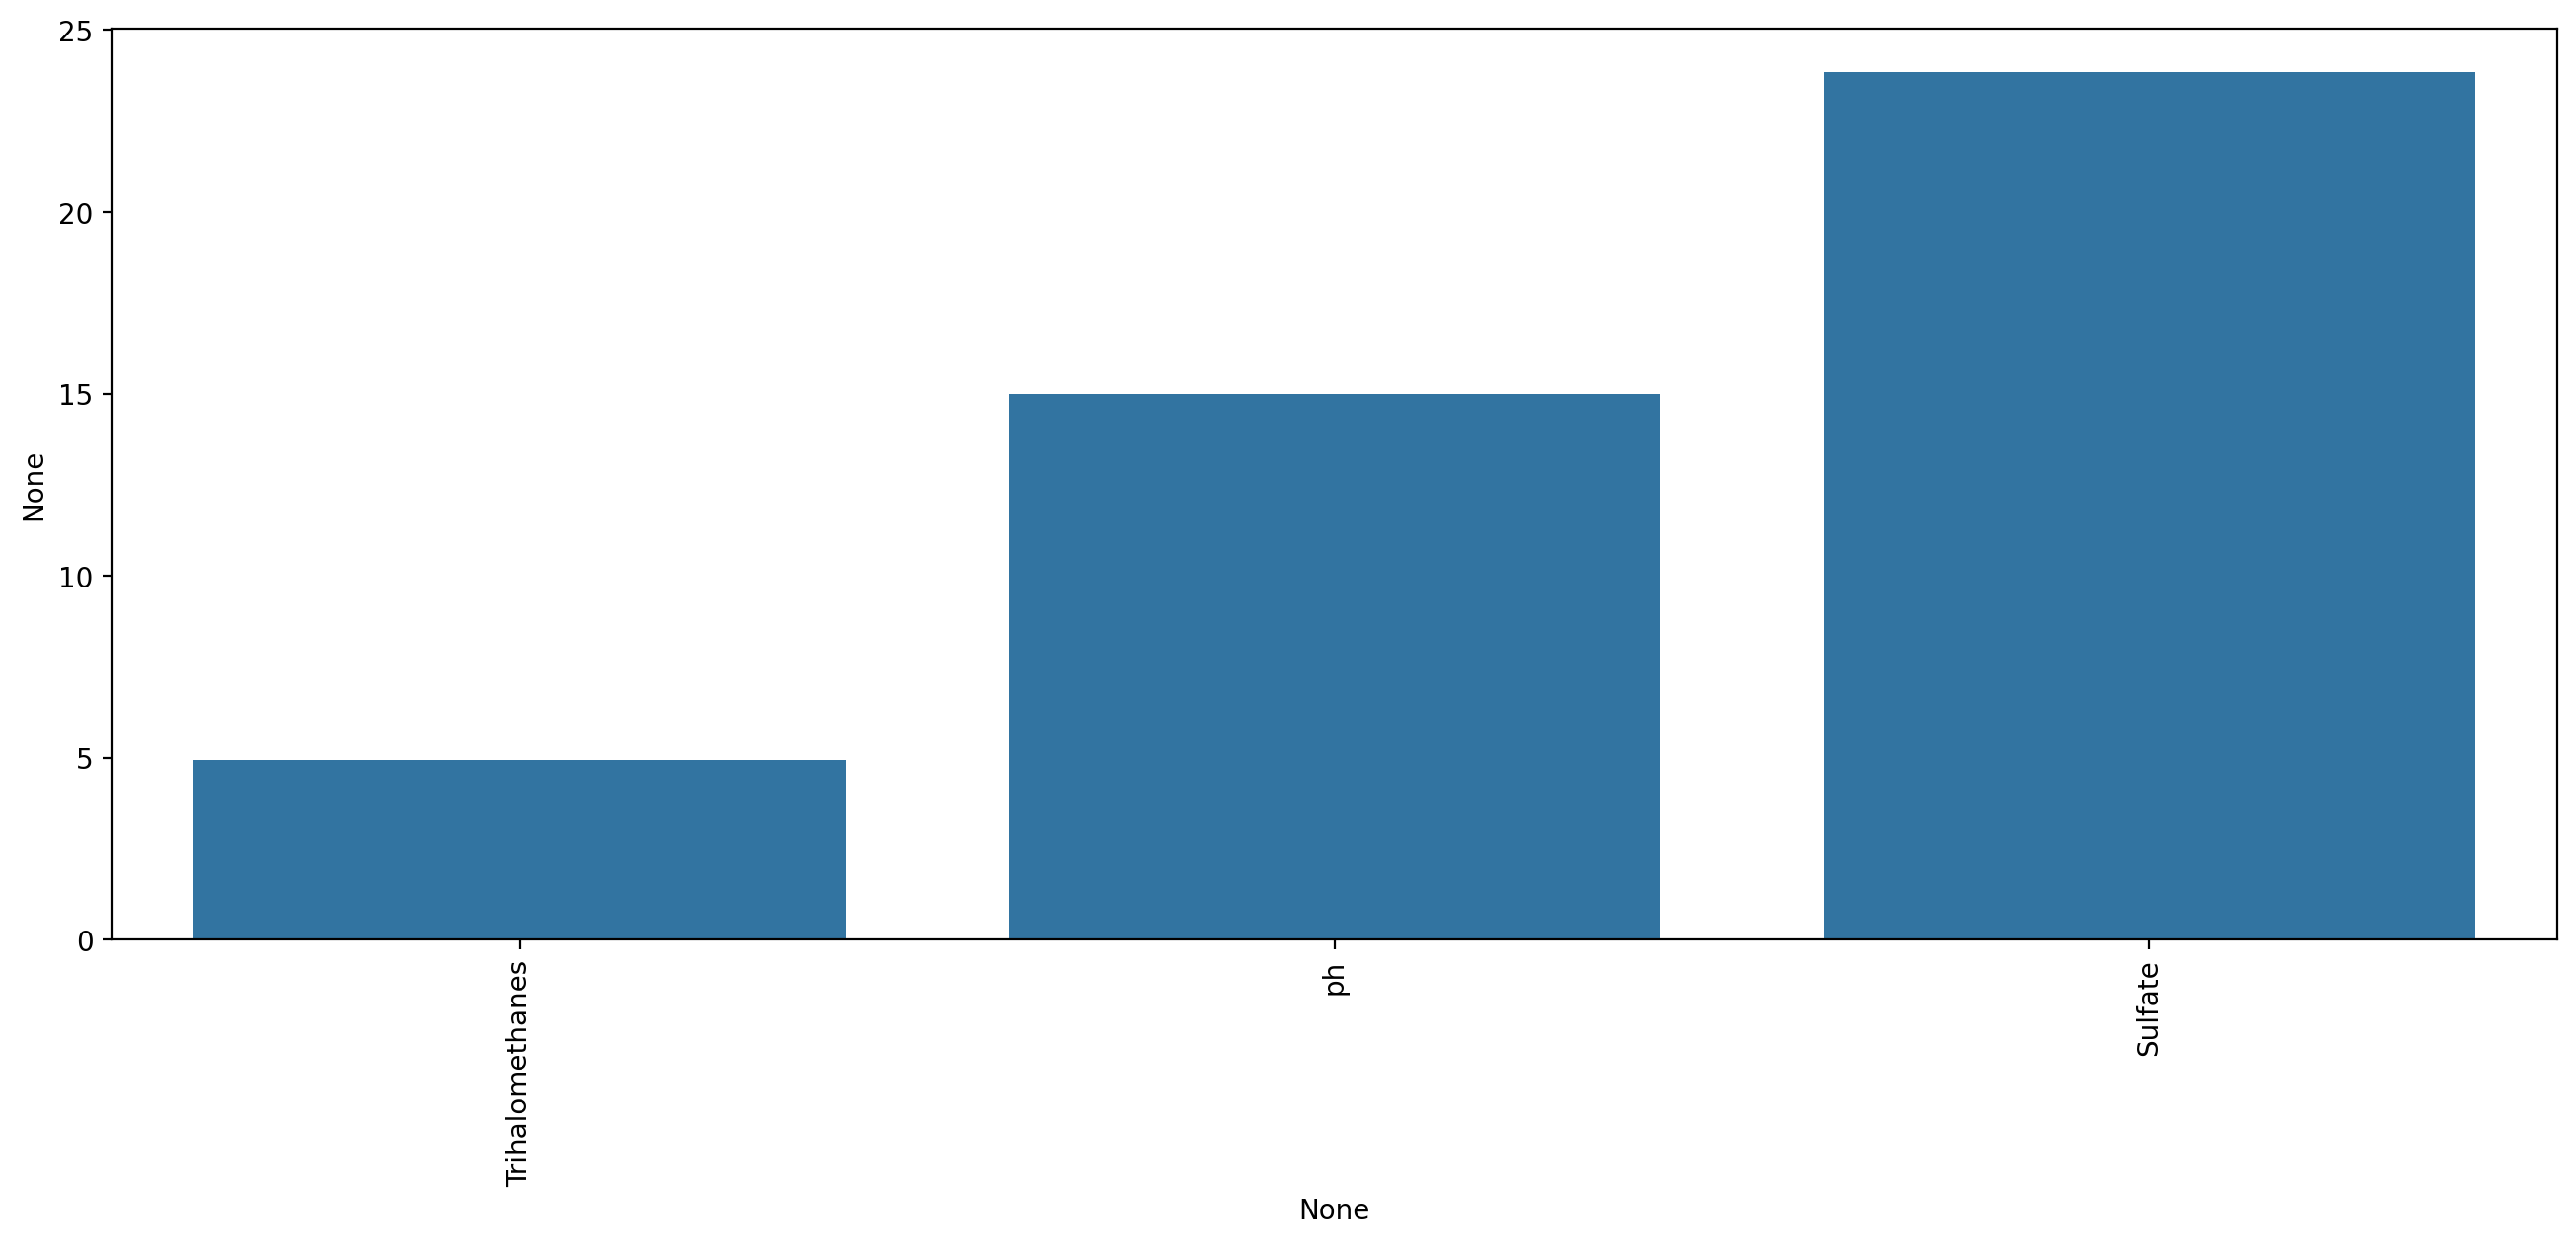

In [156]:
plt.figure(figsize=(16,6), dpi=200)
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=90)
plt.ylim()


*Correlatin Between ph and other Columns*

In [157]:
df.corr()['ph'].sort_values(ascending=False)

ph                 1.000000
Hardness           0.082096
Organic_carbon     0.043503
Conductivity       0.018614
Sulfate            0.018203
Trihalomethanes    0.003354
Potability        -0.003556
Chloramines       -0.034350
Turbidity         -0.039057
Solids            -0.089288
Name: ph, dtype: float64

*Correlatin Between Sulfate and other Columns*

In [158]:
df.corr()['Sulfate'].sort_values(ascending=False)

Sulfate            1.000000
Organic_carbon     0.030831
Chloramines        0.027244
ph                 0.018203
Turbidity         -0.011187
Conductivity      -0.016121
Potability        -0.023577
Trihalomethanes   -0.030274
Hardness          -0.106923
Solids            -0.171804
Name: Sulfate, dtype: float64

*Correlatin Between Trihalomethanes And Other Columns*

In [159]:
df.corr()['Trihalomethanes'].sort_values(ascending=False)

Trihalomethanes    1.000000
Chloramines        0.017084
Potability         0.007130
ph                 0.003354
Conductivity       0.001285
Solids            -0.009143
Hardness          -0.013013
Organic_carbon    -0.013274
Turbidity         -0.022145
Sulfate           -0.030274
Name: Trihalomethanes, dtype: float64

*Fill Missing Values*

In [160]:
df['ph'] = df.groupby('Potability')['ph'].transform(
    lambda x: x.fillna(x.mean())
)

df['Sulfate'] = df.groupby('Potability')['Sulfate'].transform(
    lambda x: x.fillna(x.mean())
)

df['Trihalomethanes'] = df.groupby('Potability')['Trihalomethanes'].transform(
    lambda x: x.fillna(x.mean())
)

In [161]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [162]:
df.head(15)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.085378,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,334.564290,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,334.564290,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,7.085378,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


*Calculate the correlation between features*

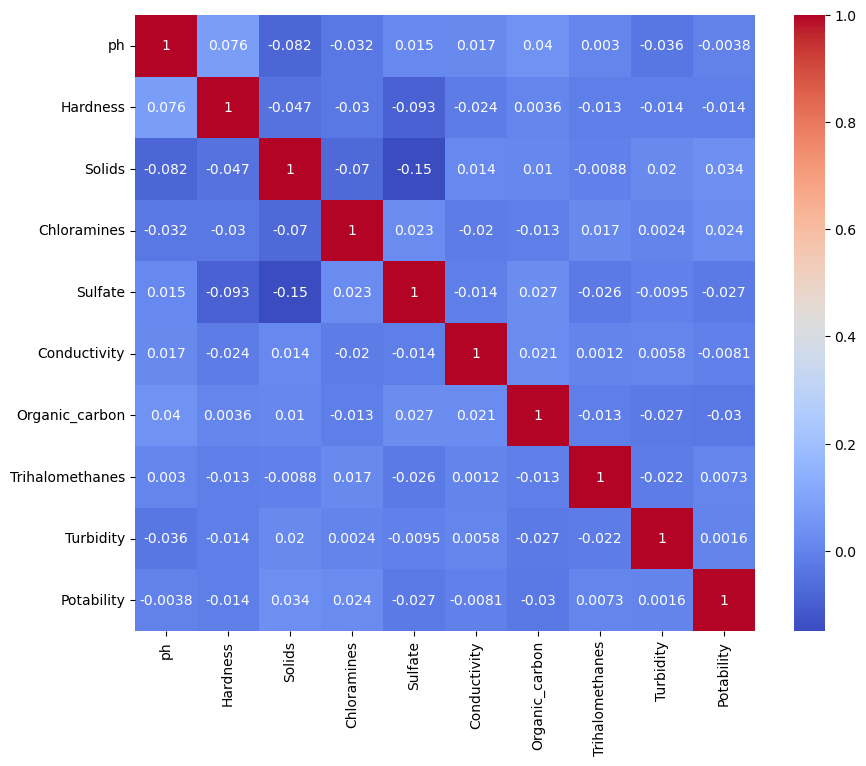

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

*Calculate the correlation between features*

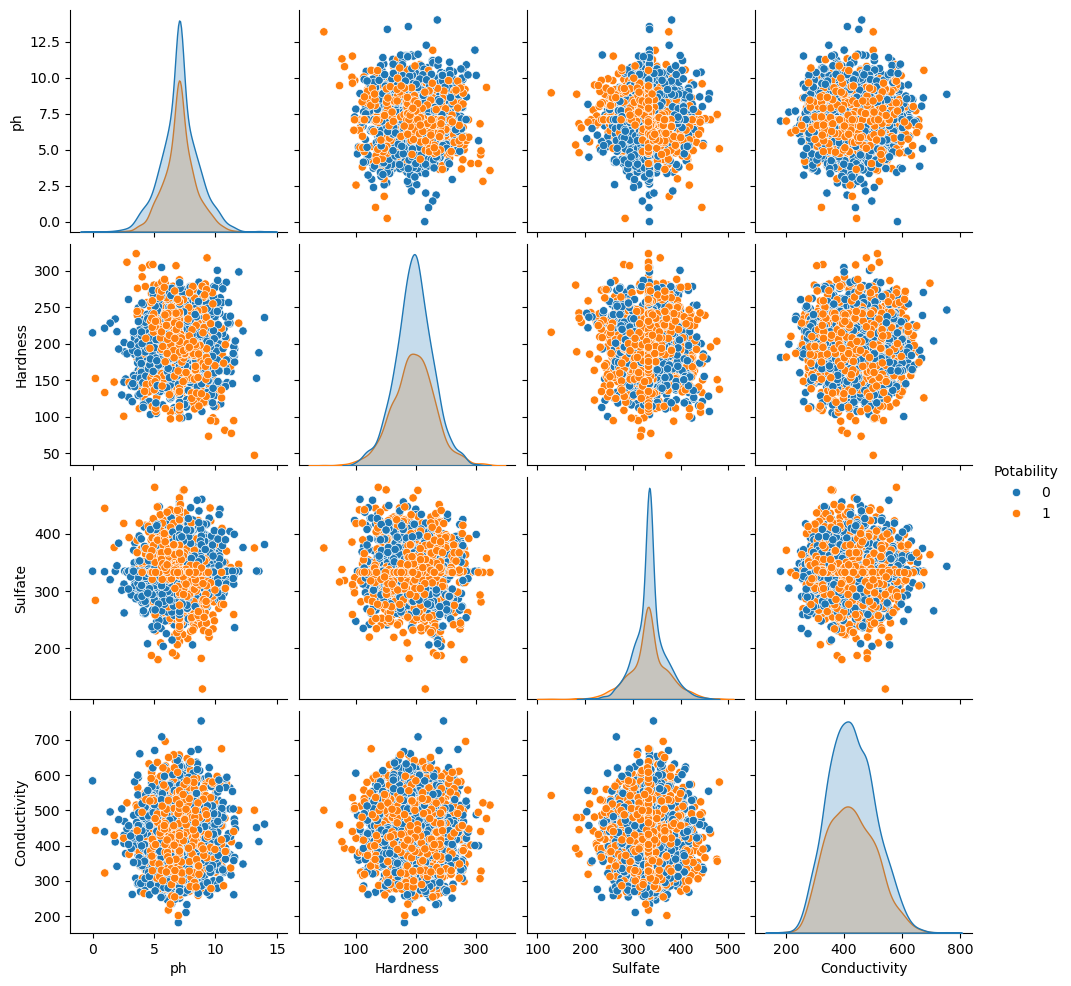

In [164]:
sns.pairplot(
    df[
        ['ph',
         'Hardness',
         'Sulfate',
         'Conductivity',
         'Potability']
    ],
    hue='Potability'
)

plt.show()

*Drop outliers*

<Axes: xlabel='ph', ylabel='Potability'>

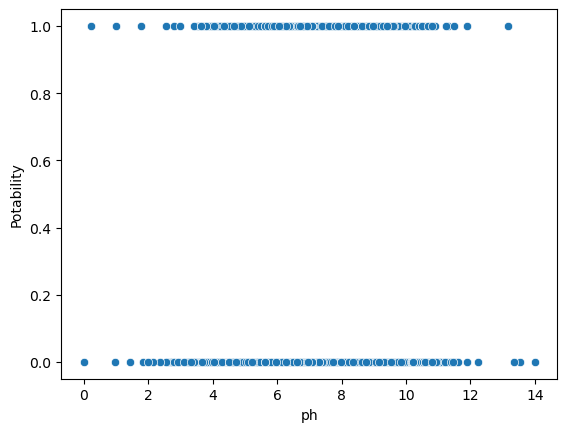

In [165]:
sns.scatterplot(data=df,x='ph',y='Potability')

*Drop outliers*

<Axes: xlabel='Hardness', ylabel='Potability'>

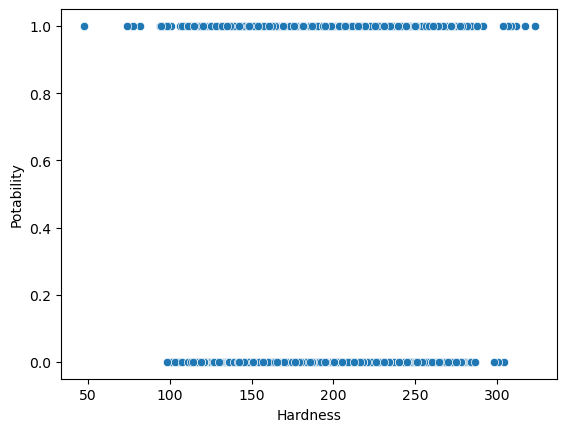

In [166]:
sns.scatterplot(data=df,x='Hardness',y='Potability')

*Drop outliers*

<Axes: xlabel='Solids', ylabel='Potability'>

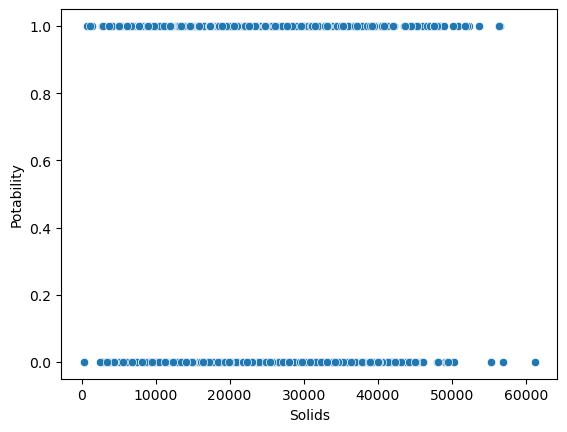

In [167]:
sns.scatterplot(data=df,x='Solids',y='Potability')

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


*Convert objects to numeric data*

In [169]:
numeric_columns=df.select_dtypes(include=['int64','Float64']).columns
numeric_columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [170]:
df[numeric_columns].corr()['Potability'].sort_values()

Organic_carbon    -0.030001
Sulfate           -0.026957
Hardness          -0.013837
Conductivity      -0.008128
ph                -0.003848
Turbidity          0.001581
Trihalomethanes    0.007305
Chloramines        0.023779
Solids             0.033743
Potability         1.000000
Name: Potability, dtype: float64

In [171]:
print(df.dtypes)

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


*Target column data distribution*

In [172]:
print(df['Potability'].value_counts())

print(df['Potability'].value_counts(normalize=True)*100)

Potability
0    1998
1    1278
Name: count, dtype: int64
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


In [173]:
df['Potability'].unique()

array([0, 1])

<Axes: xlabel='Potability', ylabel='count'>

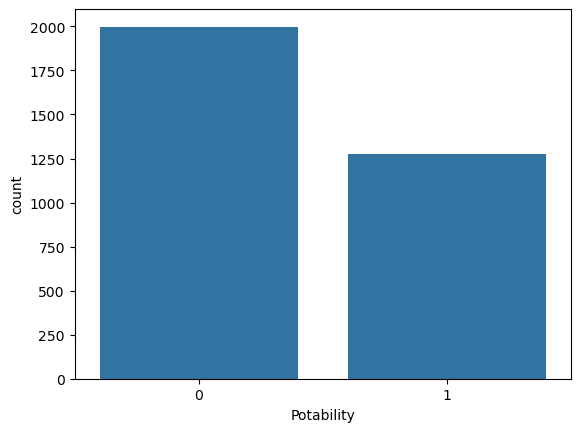

In [174]:
sns.countplot(df,x='Potability')

*Identifying Outlayers*

<Axes: xlabel='Potability', ylabel='ph'>

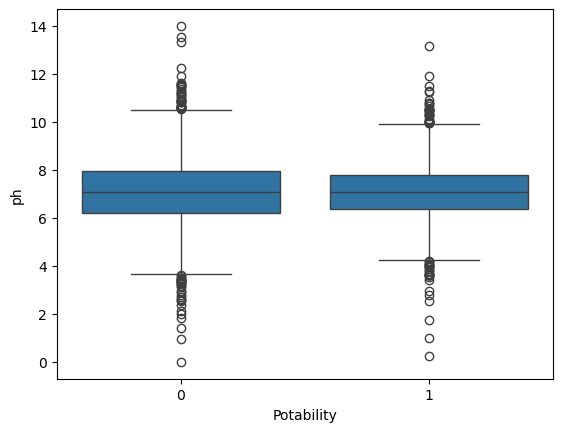

In [175]:
sns.boxplot(df,x='Potability',y='ph')

*Drop outliers*

<Axes: xlabel='Potability', ylabel='ph'>

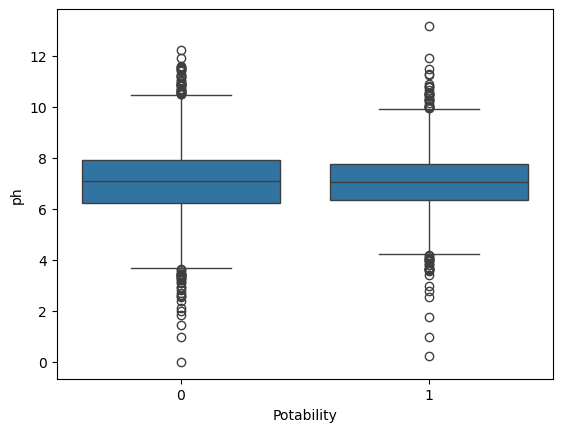

In [176]:
drop_index=df[(df['ph']>13) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
sns.boxplot(df,x='Potability',y='ph')

*Drop outliers*

<Axes: xlabel='Potability', ylabel='ph'>

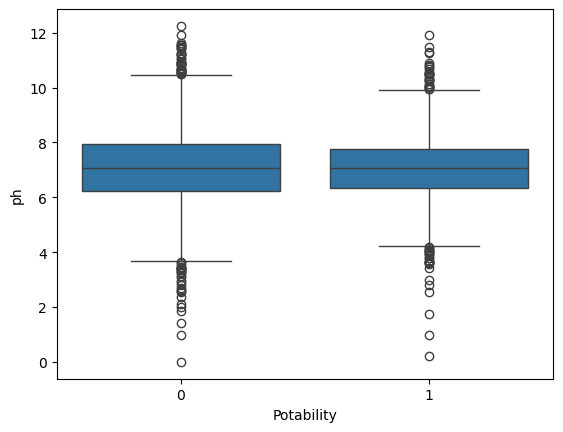

In [177]:
drop_index=df[(df['ph']>13) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
sns.boxplot(df,x='Potability',y='ph')

*Drop outliers*

<Axes: xlabel='Potability', ylabel='ph'>

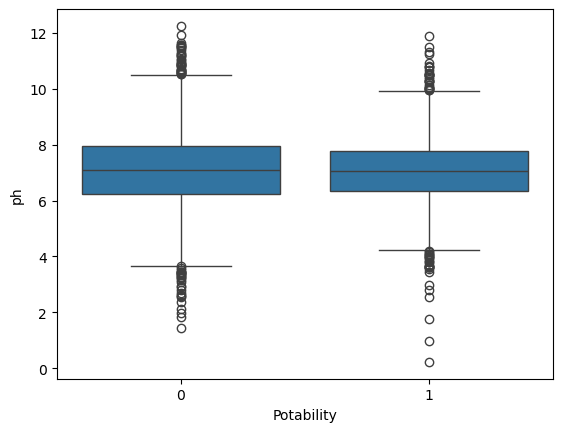

In [178]:
drop_index=df[(df['ph']<1) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
sns.boxplot(df,x='Potability',y='ph')

*Drop outliers*

<Axes: xlabel='Potability', ylabel='ph'>

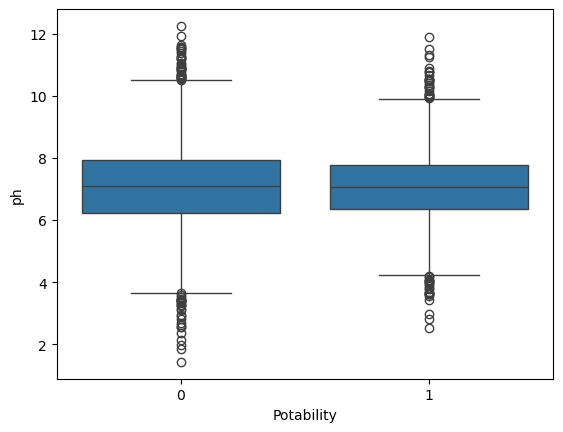

In [179]:
drop_index=df[(df['ph']<2) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
sns.boxplot(df,x='Potability',y='ph')

<Axes: xlabel='Potability', ylabel='Hardness'>

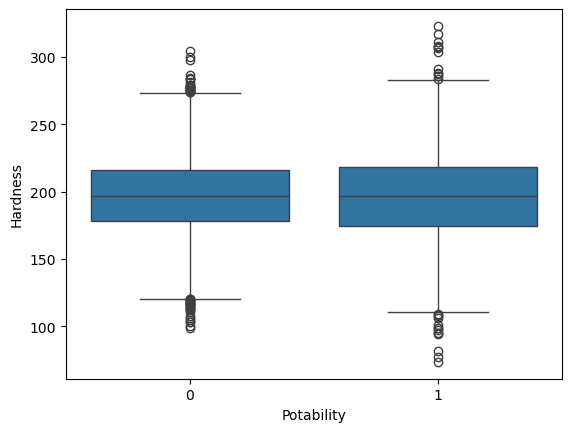

In [180]:
sns.boxplot(df,x='Potability',y='Hardness')

<Axes: xlabel='ph', ylabel='Potability'>

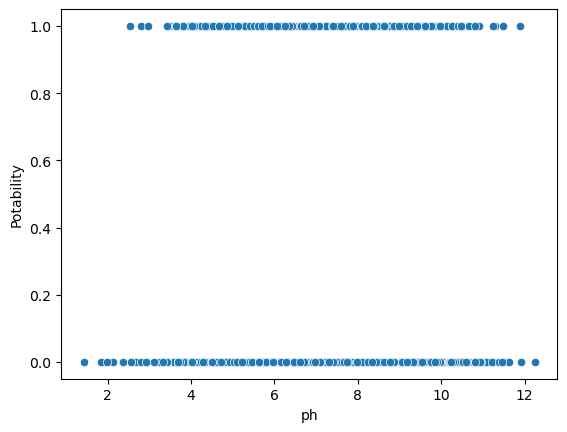

In [181]:
sns.scatterplot(df,x='ph',y='Potability')

<Axes: xlabel='Hardness', ylabel='Potability'>

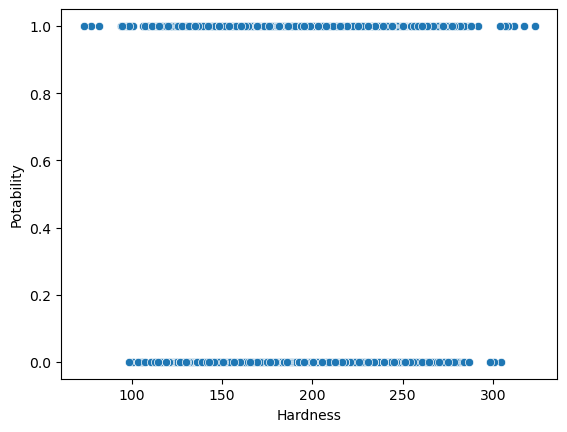

In [182]:
sns.scatterplot(df,x='Hardness',y='Potability')

*Drop outliers*

<Axes: xlabel='Hardness', ylabel='Potability'>

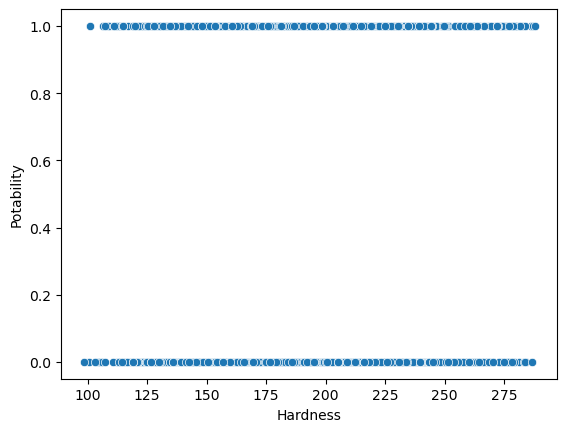

In [183]:
drop_index=df[(df['Hardness']>290) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Hardness']<100) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Hardness']>290) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
sns.scatterplot(df,x='Hardness',y='Potability')

<Axes: xlabel='Solids', ylabel='Potability'>

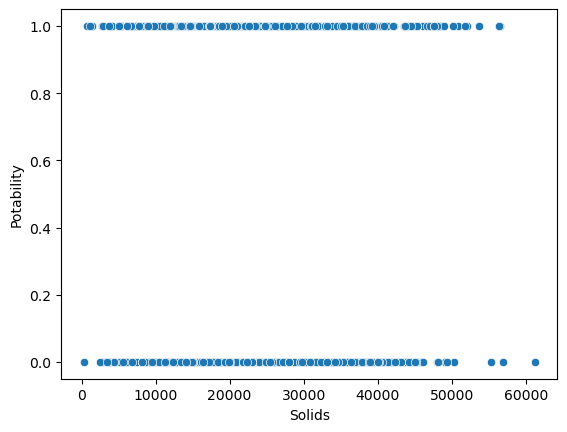

In [184]:
sns.scatterplot(df,x='Solids',y='Potability')

*Drop outliers*

<Axes: xlabel='Solids', ylabel='Potability'>

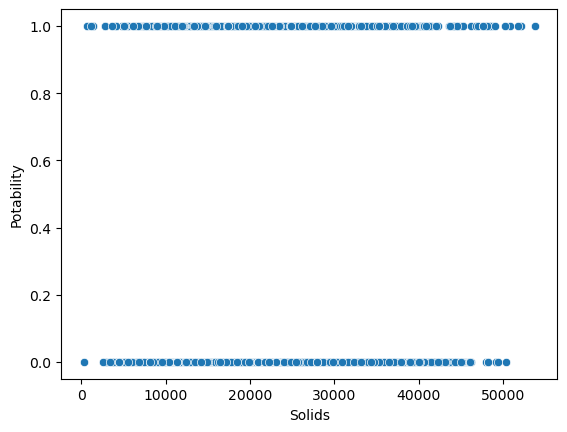

In [185]:
drop_index=df[(df['Solids']>55000) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Solids']>56000) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
sns.scatterplot(df,x='Solids',y='Potability')

<Axes: xlabel='Chloramines', ylabel='Potability'>

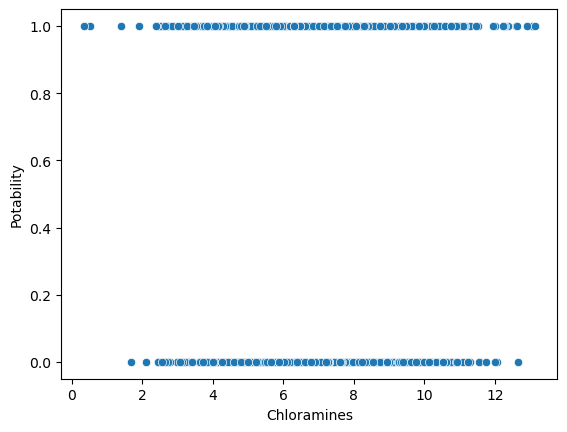

In [186]:
sns.scatterplot(df,x='Chloramines',y='Potability')

*Drop outliers*

<Axes: xlabel='Chloramines', ylabel='Potability'>

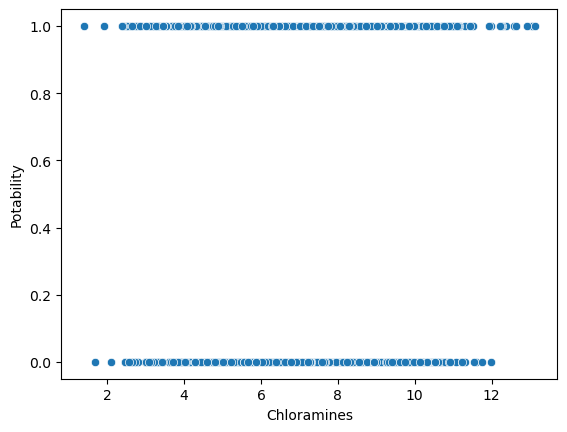

In [187]:
drop_index=df[(df['Chloramines']<0.6) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Chloramines']>12) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
sns.scatterplot(df,x='Chloramines',y='Potability')

<Axes: xlabel='Sulfate', ylabel='Potability'>

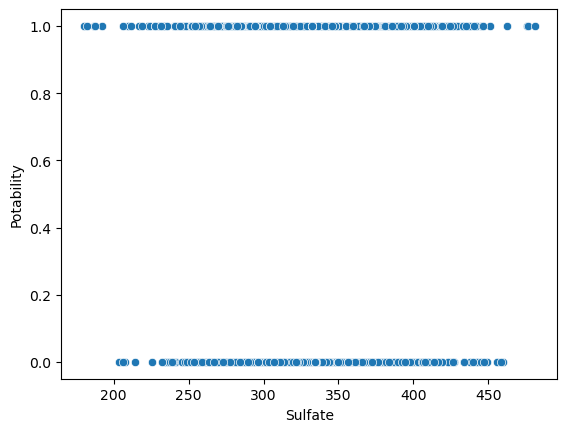

In [188]:
sns.scatterplot(df,x='Sulfate',y='Potability')

*Drop outliers*

<Axes: xlabel='Sulfate', ylabel='Potability'>

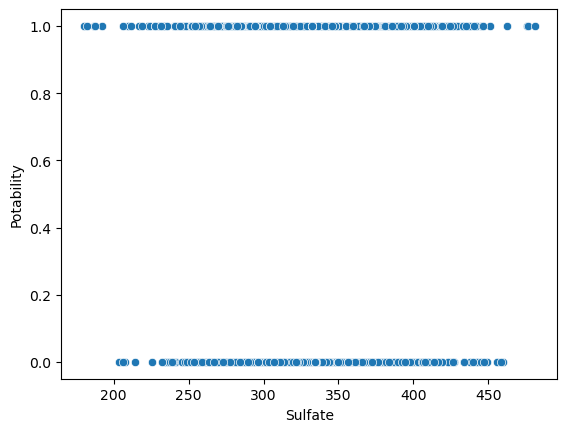

In [189]:
drop_index=df[(df['Sulfate']<150) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
sns.scatterplot(df,x='Sulfate',y='Potability')

<Axes: xlabel='Conductivity', ylabel='Potability'>

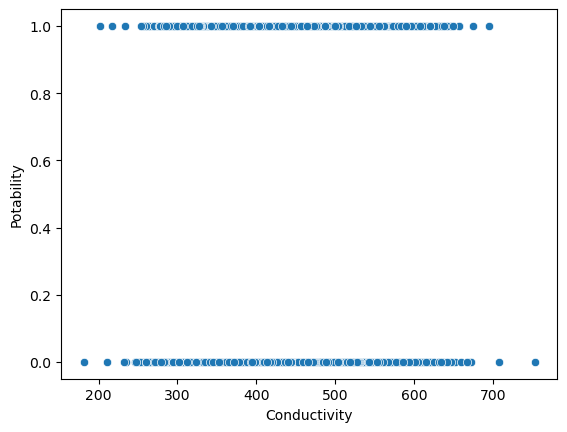

In [190]:
sns.scatterplot(df,x='Conductivity',y='Potability')

*Drop outliers*

<Axes: xlabel='Conductivity', ylabel='Potability'>

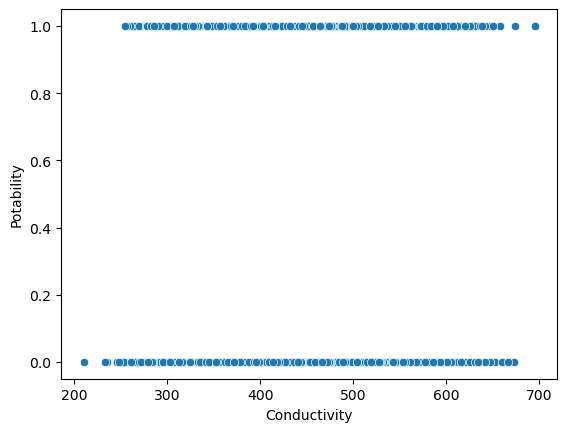

In [191]:
drop_index=df[(df['Conductivity']>700) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Conductivity']<200) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Conductivity']<250) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
sns.scatterplot(df,x='Conductivity',y='Potability')

<Axes: xlabel='Organic_carbon', ylabel='Potability'>

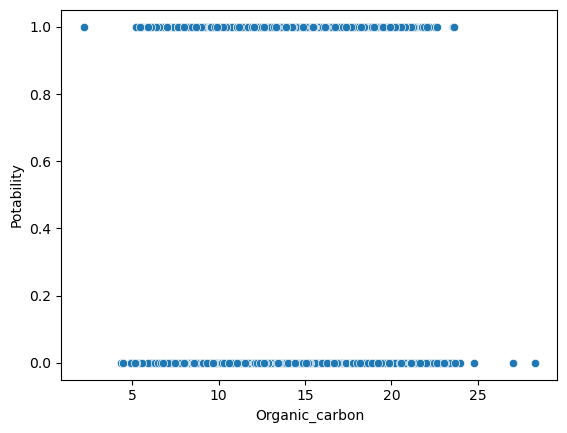

In [192]:
sns.scatterplot(df,x='Organic_carbon',y='Potability')

*Drop outliers*

<Axes: xlabel='Organic_carbon', ylabel='Potability'>

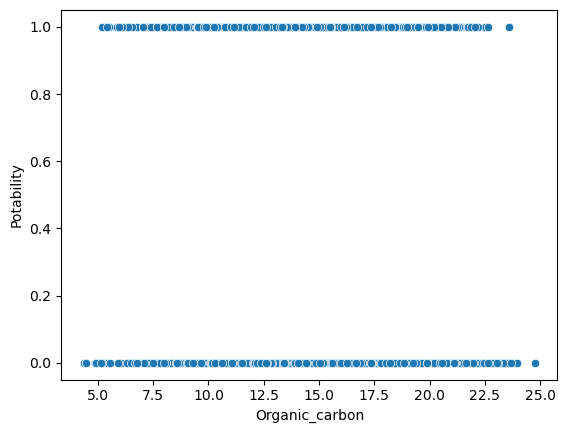

In [193]:
drop_index=df[(df['Organic_carbon']<3) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Organic_carbon']>25) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
sns.scatterplot(df,x='Organic_carbon',y='Potability')

<Axes: xlabel='Trihalomethanes', ylabel='Potability'>

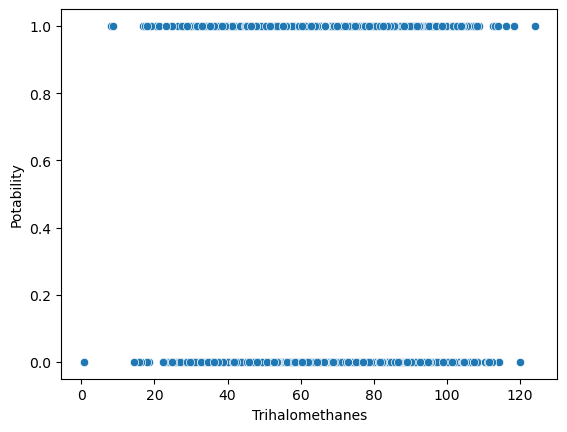

In [194]:
sns.scatterplot(df,x='Trihalomethanes',y='Potability')

*Drop outliers*

<Axes: xlabel='Trihalomethanes', ylabel='Potability'>

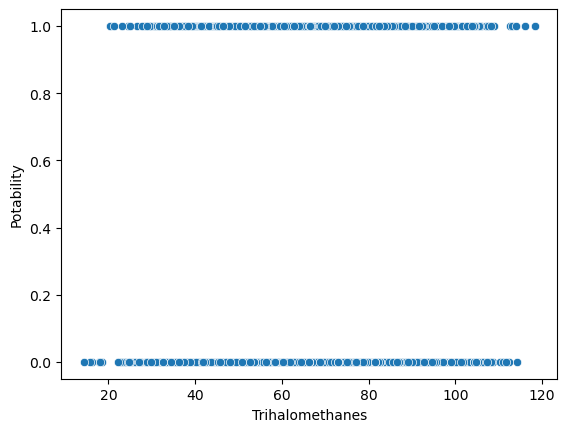

In [195]:
drop_index=df[(df['Trihalomethanes']<1) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Trihalomethanes']<20) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Trihalomethanes']>120) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
drop_index=df[(df['Trihalomethanes']>120) & (df['Potability']==1)].index
df=df.drop(drop_index,axis=0)
sns.scatterplot(df,x='Trihalomethanes',y='Potability')

*Drop outliers*

<Axes: xlabel='Turbidity', ylabel='Potability'>

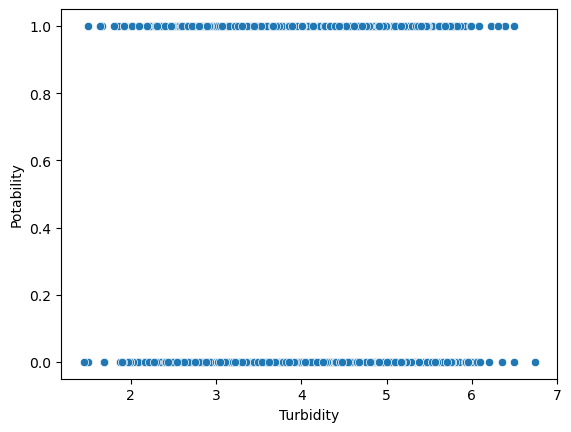

In [196]:
drop_index=df[(df['Trihalomethanes']<1) & (df['Potability']==0)].index
df=df.drop(drop_index,axis=0)
sns.scatterplot(df,x='Turbidity',y='Potability')

*Calculate the correlation between features*

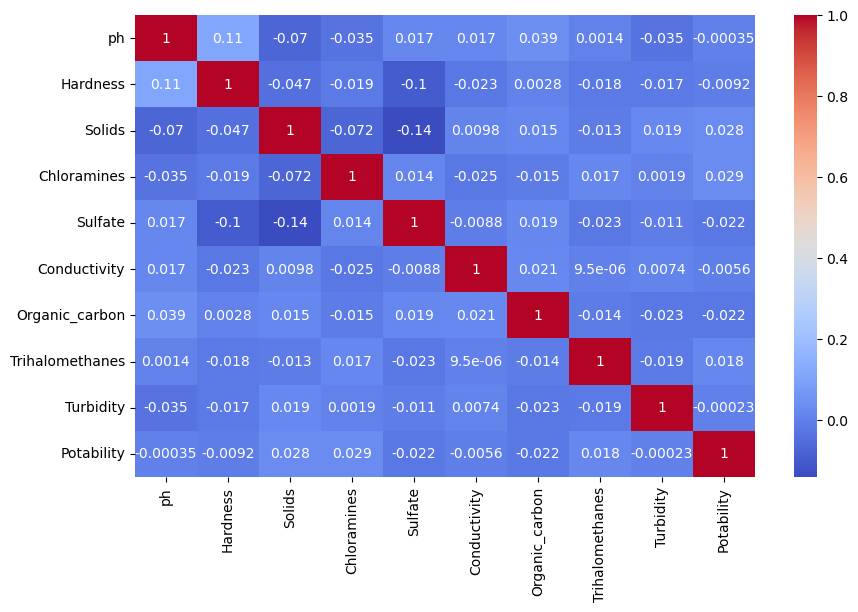

In [197]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

*Calculate the correlation between features*

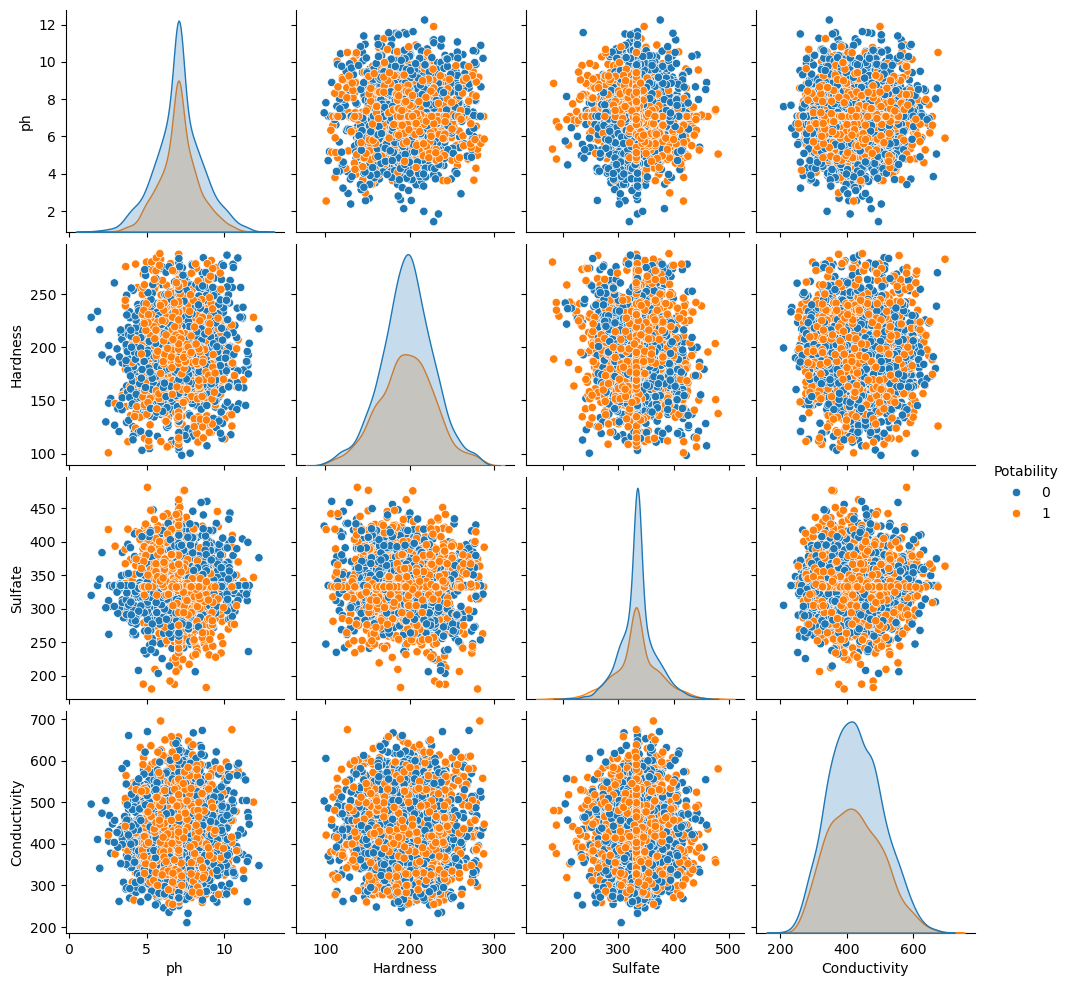

In [198]:
sns.pairplot(
    df[
        ['ph',
         'Hardness',
         'Sulfate',
         'Conductivity',
         'Potability']
    ],
    hue='Potability'
)

plt.show()

*Use clustering methods to evaluate therelationship between 2 features*

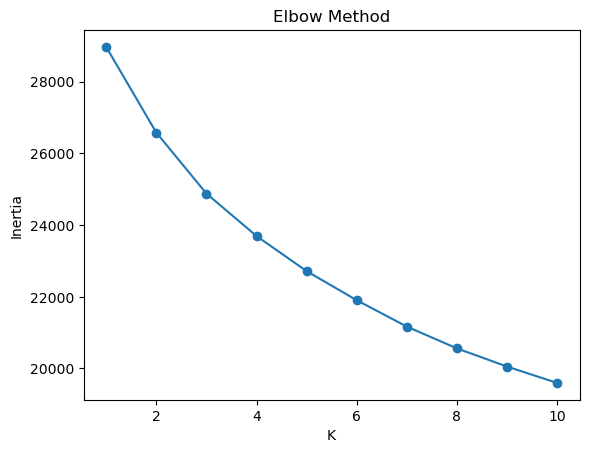

In [199]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_cluster = df.drop("Potability", axis=1)

sc_cluster = StandardScaler()

X_cluster_scaled = sc_cluster.fit_transform(X_cluster)

inertia = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_cluster_scaled)

    inertia.append(km.inertia_)

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


*Set input and output*

In [200]:
X = df.drop('Potability',axis=1)
y = df['Potability']

In [201]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

*Transform input by preprocessing (StandardScaler)*

In [202]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

*Fit and predict model by Logistic Regression*

In [203]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train,y_train)

log_pred = log_model.predict(X_test)

*Fit and predict model by KNeighborsClassifier*

In [204]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

*Fit and predict model by SVC*

In [205]:
from sklearn.svm import SVC

svc = SVC()

svc.fit(X_train,y_train)

svc_pred = svc.predict(X_test)

*Fit and predict model by Random Forest Classifier*

In [206]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

*Fit and predict model by Ada Boost Classifier*

In [207]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

ada.fit(X_train,y_train)

ada_pred = ada.predict(X_test)

*Using GridSearchCV*

In [208]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [209]:
param_grid = {
    'C':[0.1,1,10],
    'gamma':['scale','auto',0.01,0.001],
    'kernel':['rbf','linear']
}

svc_grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svc_grid.fit(X_train,y_train)

print(svc_grid.best_params_)

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


{'C': 0.01, 'class_weight': None, 'solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       198
           1       0.00      0.00      0.00       124

    accuracy                           0.61       322
   macro avg       0.31      0.50      0.38       322
weighted avg       0.38      0.61      0.47       322



c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


array([[198,   0],
       [124,   0]])

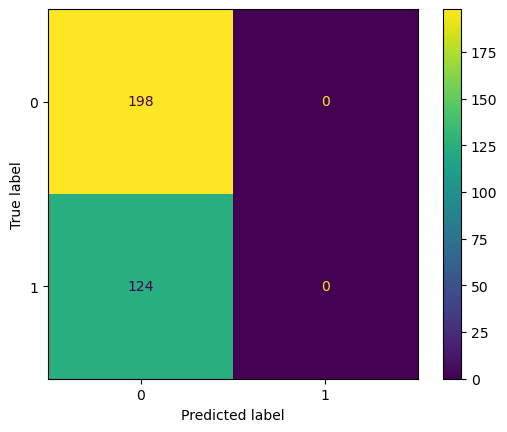

In [210]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C':[0.01,0.1,1,10,100],
    'solver':['lbfgs','liblinear'],
    'class_weight':[None,'balanced']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train,y_train)
y_pred = grid.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
print(grid.best_params_)
print(classification_report(y_test,y_pred))
ConfusionMatrixDisplay.from_estimator(grid,X_test,y_test)
1-accuracy_score(y_test,y_pred)
confusion_matrix(y_test,y_pred)



Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 19, 'weights': 'distance'}

Best Accuracy:
0.6561914120659877
Accuracy = 0.6428571428571429
              precision    recall  f1-score   support

           0       0.65      0.90      0.76       198
           1       0.59      0.23      0.34       124

    accuracy                           0.64       322
   macro avg       0.62      0.57      0.55       322
weighted avg       0.63      0.64      0.59       322



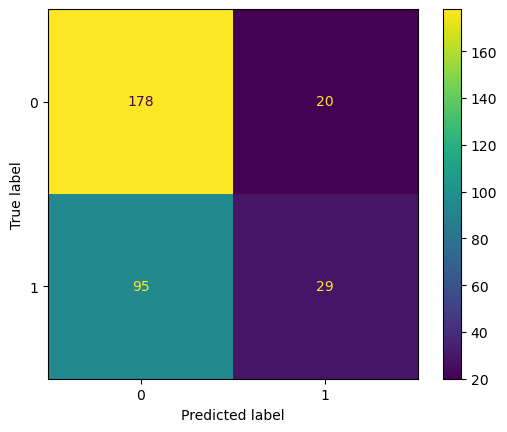

In [211]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15,17,19],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan','minkowski']
}

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Accuracy:")
print(grid.best_score_)

best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy =",accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_knn,
    X_test,
    y_test
)

Best Parameters:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Best Accuracy:
0.6820832588886903
Accuracy = 0.65527950310559
              precision    recall  f1-score   support

           0       0.65      0.93      0.77       198
           1       0.67      0.21      0.32       124

    accuracy                           0.66       322
   macro avg       0.66      0.57      0.54       322
weighted avg       0.66      0.66      0.60       322



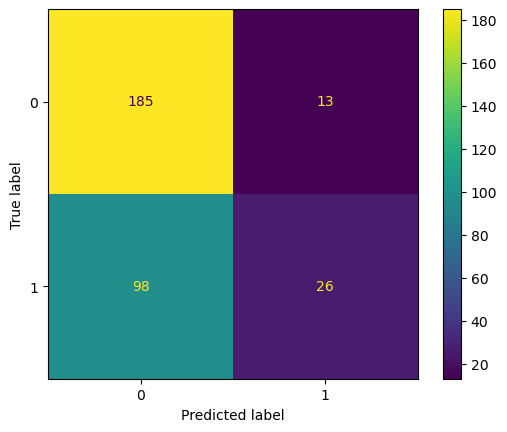

In [212]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc = SVC()

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(
    svc,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Accuracy:")
print(grid.best_score_)
best_svc = grid.best_estimator_

y_pred = best_svc.predict(X_test)
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy =", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))
confusion_matrix(y_test,y_pred)
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_svc,
    X_test,
    y_test
)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Accuracy:
0.801174438687392
Accuracy = 0.8167701863354038
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       198
           1       0.82      0.68      0.74       124

    accuracy                           0.82       322
   macro avg       0.82      0.79      0.80       322
weighted avg       0.82      0.82      0.81       322



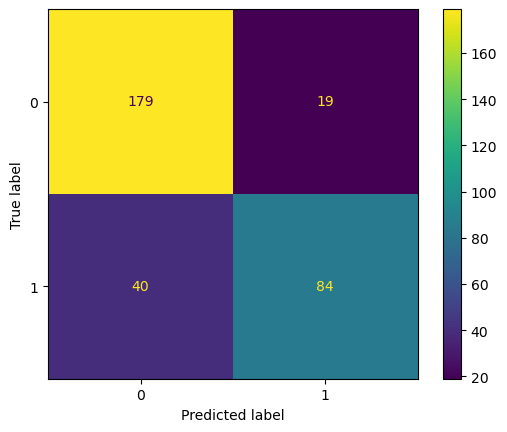

In [213]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    class_weight='balanced', random_state=42 
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Accuracy:")
print(grid.best_score_)

best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy =", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))
confusion_matrix(y_test,y_pred)
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

AdaBoost
Accuracy : 0.7267080745341615
              precision    recall  f1-score   support

           0       0.73      0.87      0.80       198
           1       0.71      0.49      0.58       124

    accuracy                           0.73       322
   macro avg       0.72      0.68      0.69       322
weighted avg       0.72      0.73      0.71       322

[[173  25]
 [ 63  61]]


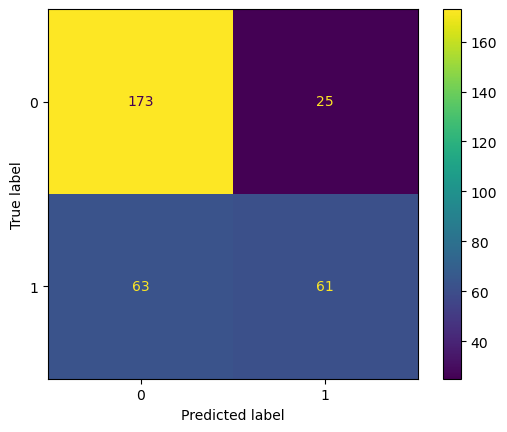

In [214]:
param_ada = {
    'n_estimators':[50,100,200,300],
    'learning_rate':[0.01,0.1,0.5,1]
}

grid_ada = GridSearchCV(
    AdaBoostClassifier(
        random_state=42
    ),
    param_ada,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_ada.fit(
    X_train,
    y_train
)

best_ada = grid_ada.best_estimator_
models = {

    "AdaBoost":best_ada
}

for name,model in models.items():

    pred = model.predict(X_test)

    print("="*60)
    print(name)

    print("Accuracy :",
          accuracy_score(y_test,pred))

    print(
        classification_report(
            y_test,
            pred
        )
    )

    print(
        confusion_matrix(
            y_test,
            pred
        )
    )
    ConfusionMatrixDisplay.from_estimator(best_ada,X_test,y_test)

Gradient Boosting
Best Parameters:
{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

Best CV Score:
0.7100300577389327

Accuracy : 0.8043478260869565
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       198
           1       0.77      0.70      0.73       124

    accuracy                           0.80       322
   macro avg       0.80      0.79      0.79       322
weighted avg       0.80      0.80      0.80       322

[[172  26]
 [ 37  87]]


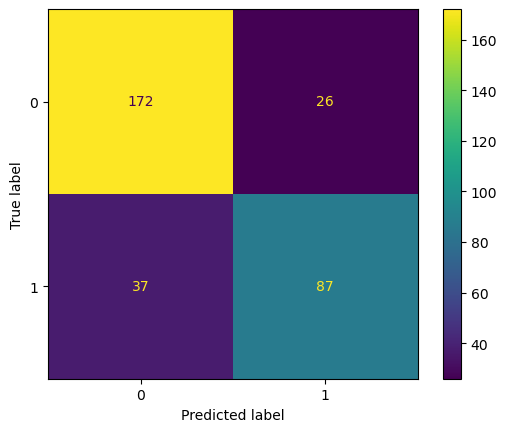

In [215]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

param_gb = {
    'n_estimators':[50,100,200,300],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'max_depth':[2,3,4],
    'subsample':[0.8,1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(
        random_state=42
    ),
    param_gb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_gb.fit(
    X_train,
    y_train
)

best_gb = grid_gb.best_estimator_

models = {
    "Gradient Boosting":best_gb
}

for name,model in models.items():

    pred = model.predict(X_test)

    print("="*60)
    print(name)

    print("Best Parameters:")
    print(grid_gb.best_params_)

    print("\nBest CV Score:")
    print(grid_gb.best_score_)

    print("\nAccuracy :",
          accuracy_score(y_test,pred))

    print(
        classification_report(
            y_test,
            pred
        )
    )

    print(
        confusion_matrix(
            y_test,
            pred
        )
    )
    ConfusionMatrixDisplay.from_estimator(best_gb,X_test,y_test)

*Clustering*

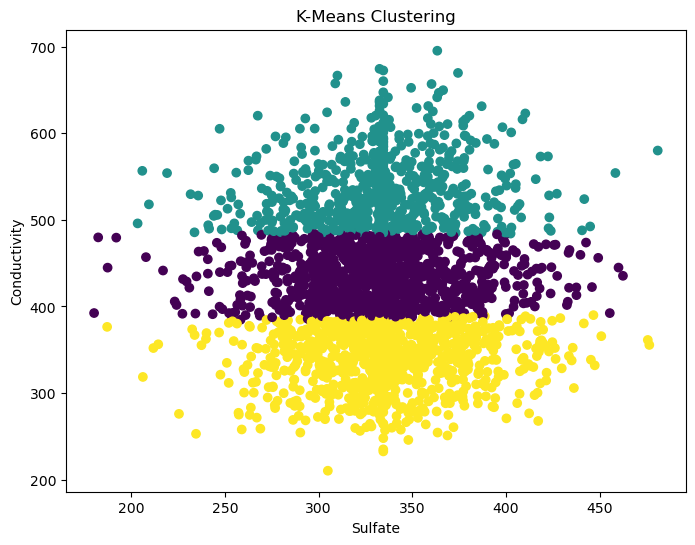

In [216]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_cluster = df[['Sulfate','Conductivity']]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(8,6))

plt.scatter(
    X_cluster['Sulfate'],
    X_cluster['Conductivity'],
    c=clusters
)

plt.xlabel('Sulfate')
plt.ylabel('Conductivity')
plt.title('K-Means Clustering')

plt.show()

*Clustering Center*

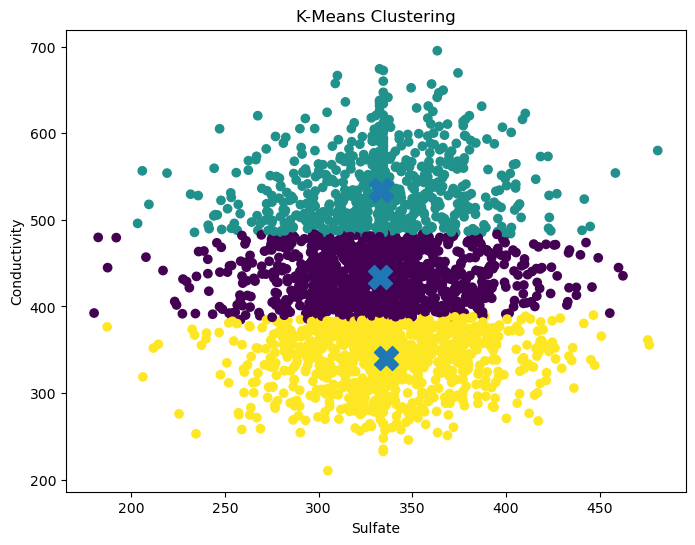

In [217]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_cluster = df[['Sulfate','Conductivity']]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster)

centers = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

plt.scatter(
    X_cluster['Sulfate'],
    X_cluster['Conductivity'],
    c=clusters
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker='X',
    s=300
)

plt.xlabel('Sulfate')
plt.ylabel('Conductivity')
plt.title('K-Means Clustering')

plt.show()

In [218]:
for col in df.columns:
    print(col)
    print("Min =",df[col].min())
    print("Max =",df[col].max())

ph
Min = 1.4317815547427415
Max = 12.246928068519756
Hardness
Min = 98.45293050958628
Max = 287.9755402021361
Solids
Min = 320.942611274359
Max = 53735.89919386698
Chloramines
Min = 1.3908709048851806
Max = 13.127000000000002
Sulfate
Min = 180.20674636482343
Max = 481.0306423059972
Conductivity
Min = 210.31918197203672
Max = 695.3695279880473
Organic_carbon
Min = 4.371898608441143
Max = 24.75539236988334
Trihalomethanes
Min = 14.343161445011162
Max = 118.3572747362022
Turbidity
Min = 1.45
Max = 6.739
Potability
Min = 0
Max = 1
